LINEAR REGRESSION ANALYSIS OF JAMBOREE DATASET BASED ON MARKS SCORED IN DIFFERENT EXAMS AND CHANCES OF GETTING COLLEGE ADDMISSION

AJITESH SOLANKI 2333304
REET AGARWAL 2333338
VANDITHA PATWARY 2333356

25TH FEBRUARY 2025

# Brief Description
-This project applies linear regression using Python to analyze the determinants of a student’s probability of admission to graduate programs. The dataset contains academic and profile-related variables such as GRE score, TOEFL score, CGPA, university rating, SOP strength, LOR strength, and research experience.

The dependent variable is Chance of Admit, which represents the probability of admission (ranging between 0 and 1).

The objective is to estimate how different academic and profile factors influence admission probability and quantify their marginal impact using a linear regression model.

------------------------------------------------------------------------------------------------------------------------------------------------

# Introduction

Admission to competitive graduate programs depends on multiple measurable factors such as standardized test scores, academic performance, institutional reputation, and research exposure.

With increasing competition in higher education, understanding which factors significantly influence admission chances becomes important for both students and educational consultants.

Linear regression provides a statistical framework to:

Measure the strength of relationships

Estimate the impact of each predictor variable

Evaluate model fit and explanatory power

This project uses Python (likely pandas, numpy, statsmodels, or sklearn) to build and evaluate a regression model that explains variation in admission probability.

----------------------------------------------------------------------------------------------------------------------------------------------------

# PROJECT OBJECTIVE

1. The primary objectives of this project are:

2. To build a multiple linear regression model predicting Chance of Admit.

3. To examine the statistical significance of independent variables.

4. To measure the magnitude of impact (coefficients) of:

        -GRE Score

        -TOEFL Score

        -University Rating

        -SOP

        -LOR

        -CGPA

        -Research

5. To evaluate model performance using:

        -R-squared

        -Adjusted R-squared

        -p-values

        -Residual diagnostics

6. To interpret the economic/academic meaning of coefficients.

-------------------------------------------------------------------------------------------------------------------------------------------

# PROBLEM STATEMENT

Despite having strong academic credentials, not all students receive admission offers. It is unclear which factors play the most decisive role and how much each factor contributes to admission probability.

The key research question is:

"How do academic performance indicators and profile characteristics influence the probability of admission to graduate programs?"

More specifically:

     -Does CGPA have a stronger impact than GRE?
 
     -How important is research experience?

     -Do qualitative measures (SOP, LOR) significantly affect admission probability?

     -How well can these variables jointly explain variation in admission outcomes?

---------------------------------------------------------------------------------------------------------------------------

# DATASET DESCRIPTION AND DATASET OVERVIEW

### Dataset Overview

        Total Observations: 500

        Total Variables: 9

        No missing values

        All variables are numeric

### Variables Description

    Serial No.
        Unique identifier for each observation (not used in regression).

    GRE Score
        Graduate Record Examination score (range typically 260–340).

    TOEFL Score
        English proficiency score (range typically 0–120).

    University Rating
        Rating of undergraduate institution (scale 1–5).

    SOP
        Strength of Statement of Purpose (scale 1–5).

    LOR
        Strength of Letter of Recommendation (scale 1–5).

    CGPA
        Undergraduate cumulative grade point average (on 10-point scale).

    Research
        Binary variable:

1 = Research experience

0 = No research experience

Chance of Admit (Dependent Variable)
Probability of admission (continuous variable between 0 and 1).

------------------------------------------------------------------------------------------------------------------------------------------

# DATASET SOURCE- https://www.kaggle.com/datasets/ranitsarkar01/jamboree-linear-regression-dataset

-------------------------------------------------------------------------------------------------------------------------------------------------

# Suggested Regression Model Specification

Econometric model will look like:

ChanceOfAdmit_i = β0 + β1 GRE_i + β2 TOEFL_i + β3 UniversityRating_i + β4 SOP_i + β5 LOR_i + β6 CGPA_i + β7 Research_i + ε_i

Where:
   
    ε_i = error term
    
    βj= marginal effect of each variable

---------------------------------------------------------------------------------------------------------------------------------------------

# CODE

In [1]:
#STEP 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#STEP 2: Load Dataset

df = pd.read_csv("jamboree_dataset.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [3]:
#This removes hidden leading/trailing spaces.

df.columns = df.columns.str.strip()
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance of Admit'],
      dtype='object')

In [4]:
#STEP 3: Data Cleaning

#Drop Serial Number (not needed in regression)

df = df.drop("Serial No.", axis=1)
df.head()

#Check missing values:
df.isnull().sum()

GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [5]:
#STEP 4: Define Dependent and Independent Variables

#Dependent variable (Y):
y = df["Chance of Admit"]

#Independent variables (X):
X = df.drop("Chance of Admit", axis=1)


In [6]:
#STEP 5: Add Constant (Very Important in OLS)

X = sm.add_constant(X)

In [7]:
#STEP 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [8]:
#STEP 7: Run the Regression
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     242.7
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          1.72e-133
Time:                        23:26:23   Log-Likelihood:                 525.52
No. Observations:                 375   AIC:                            -1035.
Df Residuals:                     367   BIC:                            -1004.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4041      0.12

#STEP 8: Interpret the Results



# 1. R-squared: 0.822

### What it means:

* The model explains **82.2%** of the variance in *Chance of Admit*.
* Only **17.8%** of the variation remains unexplained.

### Interpretation:

* This is a **very strong model fit**.
* The independent variables (GRE, TOEFL, CGPA, LOR, Research, etc.) collectively explain most of the variation in admission probability.
* The model has high explanatory power.

---

# 2. Adjusted R-squared: 0.819

### What it means:

* Adjusted R² accounts for the number of predictors in the model.
* It penalizes unnecessary variables.

### Interpretation:

* Adjusted R² (0.819) is very close to R² (0.822).
* This indicates:

  * The predictors are meaningful.
  * The model is not artificially inflated by irrelevant variables.
* The model remains strong even after adjusting for the number of predictors.

---

# 3. F-statistic: 242.7

### Prob (F-statistic): 1.72e-133

### What it tests:

* **H₀:** All slope coefficients = 0 (no linear relationship).
* **H₁:** At least one coefficient ≠ 0.

### Interpretation:

* The p-value is **extremely small** (≈ 0.000).
* Since p < 0.05, we **reject the null hypothesis**.
* The model is **highly statistically significant overall**.
* At least one predictor significantly affects admission probability.

Conclusion:
The regression model as a whole is statistically significant.

---

# 4. Individual Coefficient Interpretation

We check p-values (< 0.05 = significant).

### Significant Variables:

#### GRE Score (p = 0.000)

* Positive coefficient (0.0022)
* A 1-point increase in GRE increases admission probability by 0.22 percentage points (holding other variables constant).
* Statistically significant.

#### TOEFL Score (p = 0.001)

* Positive effect.
* Higher TOEFL scores increase admission probability.
* Statistically significant.

#### LOR (p = 0.000)

* Strong positive effect (0.0171).
* Better recommendation letters significantly increase admission probability.

#### CGPA (p = 0.000)

* Largest coefficient (0.1168).
* A 1-point increase in CGPA increases admission probability by 11.68 percentage points.
* This is the **most influential variable**.
* Highly significant.

#### Research (p = 0.002)

* Students with research experience have 2.41 percentage points higher admission probability.
* Statistically significant.

---

### Not Significant Variables:

#### University Rating (p = 0.590)

* Not statistically significant.
* Institutional rating does not significantly affect admission once other factors are controlled.

#### SOP (p = 0.816)

* Not statistically significant.
* Statement of Purpose does not have independent explanatory power in this model.

---

# 5. Diagnostic Statistics

### Durbin-Watson: 2.075

* Close to 2 → No serious autocorrelation.
* Good sign.

### Omnibus / Jarque-Bera (p = 0.000)

* Residuals are not perfectly normal.
* However, with 375 observations, large sample size reduces concern (Central Limit Theorem).

### Condition Number: 1.38e+04

* Quite large.
* Indicates possible multicollinearity.
* Likely correlation between GRE and TOEFL or CGPA.
* Should confirm using VIF.

---

# 6. How to Describe These Results in a Report

Here is your final structured paragraph:

> We conducted a multiple linear regression analysis to predict the probability of admission using GRE score, TOEFL score, university rating, SOP strength, LOR strength, CGPA, and research experience as predictors. The overall model was statistically significant (F(7, 367) = 242.7, p < 0.001), indicating that the predictors collectively explain a significant portion of variation in admission probability. The model explained 82.2% of the variance (R² = 0.822), suggesting a strong fit. The adjusted R-squared (0.819) confirms that the model retains high explanatory power after accounting for the number of predictors. Among the variables, CGPA emerged as the most influential predictor, followed by GRE score, TOEFL score, LOR strength, and research experience, all of which were statistically significant. University rating and SOP were not statistically significant. These results suggest that academic performance and research experience are the primary determinants of admission probability in this dataset.

---

# Final Academic Insight (Very Important)

Your model is:

* Strong
* Statistically significant
* Economically meaningful

Main drivers of admission:

1. CGPA (dominant factor)
2. GRE
3. TOEFL
4. LOR
5. Research

University reputation and SOP do not add independent explanatory power once academic performance is controlled.

In [9]:
#STEP 9: Make Predictions on Test Data

y_pred = model.predict(X_test)
y_pred[:5]

361    0.915816
73     0.796744
374    0.569097
155    0.709457
104    0.816501
dtype: float64

In [10]:
#STEP 10: Evaluate Model Performance (Out-of-Sample)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("Test R-squared:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Test R-squared: 0.8163213016062116
RMSE: 0.05988096769101391


### STEP 11: Compare Train vs Test R²

The model’s training R-squared was 0.822, while the test R-squared was 0.816. The very small difference between these values indicates that the model performs consistently on both training and unseen data. This suggests that the model does not suffer from overfitting and has strong generalization ability. In other words, the predictors are not merely capturing noise in the training sample but are identifying genuine patterns that also hold in the test data.

The Root Mean Squared Error (RMSE) was 0.0599, implying that the model’s predictions deviate from the actual admission probabilities by approximately 6 percentage points on average. Given that the dependent variable ranges between 0 and 1, this represents a relatively low prediction error. Overall, the results demonstrate that the regression model is stable, reliable, and has strong explanatory as well as predictive power.

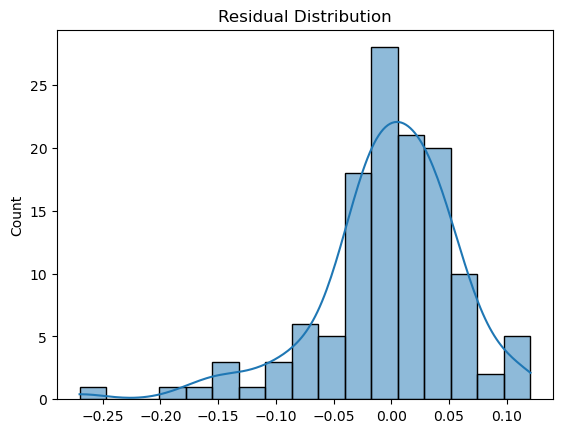

In [11]:
#STEP 12: Residual Analysis (Econometrics Requirement)

residuals = y_test - y_pred

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [12]:
#STEP 13: Check Multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) 
                   for i in range(X_train.shape[1])]

print(vif_data)

             Feature          VIF
0              const  1704.327640
1          GRE Score     4.570935
2        TOEFL Score     3.643347
3  University Rating     2.649067
4                SOP     2.774348
5                LOR     1.981965
6               CGPA     4.666216
7           Research     1.534010



# Interpretation of VIF Results

Variance Inflation Factor (VIF) measures the extent of multicollinearity among independent variables. A VIF value:

* Less than 5 → acceptable
* Between 5 and 10 → moderate multicollinearity
* Greater than 10 → serious multicollinearity

### Your Results:

* **GRE Score (4.57)** → Moderate but acceptable
* **CGPA (4.67)** → Moderate but acceptable
* **TOEFL Score (3.64)** → Acceptable
* **University Rating (2.65)** → Low
* **SOP (2.77)** → Low
* **LOR (1.98)** → Very low
* **Research (1.53)** → Very low

The intercept (const) has a very high VIF (1704), but this is not a concern because the constant term is not interpreted as a predictor and often shows inflated VIF values.

---

# Conclusion

There is **no serious multicollinearity problem** in the model. Although GRE and CGPA show moderately higher VIF values, they remain below the critical threshold of 5. Therefore, the regression estimates are stable and reliable, and multicollinearity does not significantly distort the coefficient estimates.


In [13]:
#STEP 14 CORRELATION

import seaborn as sns
import matplotlib.pyplot as plt

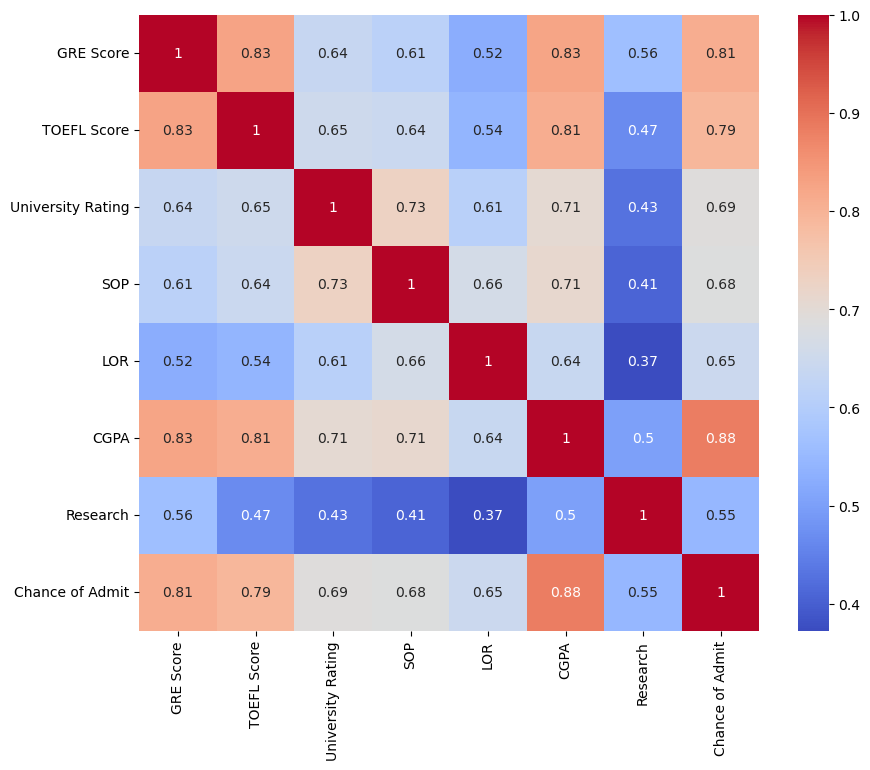

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

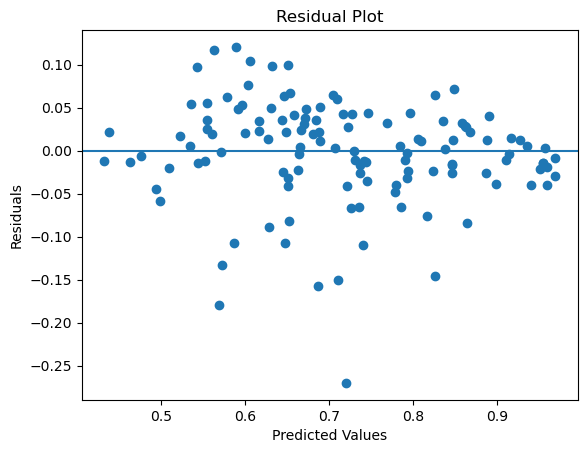

In [15]:
#STEP 15 RESIDUAL DIAGNOSTIC 

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# POLICY IMPLICATIONS

The findings of this study have important implications for students, universities, and academic advisors. Since CGPA was identified as the strongest determinant of admission probability, students should prioritize maintaining consistent academic performance throughout their undergraduate studies. While standardized test scores such as GRE and TOEFL remain significant, their impact is comparatively smaller than that of CGPA, suggesting that sustained academic achievement outweighs one-time examination performance.

The positive and significant effect of research experience implies that universities value demonstrated academic engagement beyond coursework. Therefore, students aiming for competitive graduate programs should actively pursue research opportunities, internships, or academic projects. Strong letters of recommendation also play a meaningful role, indicating that building professional academic relationships is strategically important.

Interestingly, university rating and SOP were not statistically significant once other variables were controlled for. This suggests that admissions decisions may be more merit-based and performance-driven rather than solely dependent on institutional background or subjective statements. For policymakers and educational institutions, the results highlight the importance of strengthening research exposure and academic rigor at the undergraduate level to improve graduate admission outcomes.

# CONCLUSION

This study employed multiple linear regression to examine the determinants of admission probability using GRE score, TOEFL score, university rating, SOP strength, LOR strength, CGPA, and research experience as explanatory variables. The model demonstrated strong explanatory power, with an R-squared of 0.822 and an adjusted R-squared of 0.819, indicating that over 82% of the variation in admission probability is explained by the included predictors. The overall model was highly statistically significant, as reflected by the F-statistic (p < 0.001), confirming that the predictors collectively have a meaningful linear relationship with admission outcomes.

Among the variables, CGPA emerged as the most influential factor, followed by GRE score, TOEFL score, LOR strength, and research experience. University rating and SOP were not statistically significant after controlling for other variables. The comparison between training and test R-squared values showed minimal difference, indicating strong generalization and no evidence of overfitting. Additionally, VIF results suggested no serious multicollinearity concerns. Overall, the model is statistically robust, economically meaningful, and predictively reliable.